# Proyecto Dataset Diabético

## 📊 Resumen del Dataset

- **Dimensiones**: 101,766 registros × 50 columnas
- **Variable objetivo**: `readmitted` (NO, <30 días, >30 días)
- **Tipo de problema**: Clasificación multiclase (puede convertirse a binaria)

---


In [7]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

## Limpieza y Preprocesamiento de Datos

In [8]:
df = pd.read_csv("diabetic_data.csv")
    
print(f"\n✓ Dataset cargado exitosamente")
print(f"  Dimensiones originales: {df.shape[0]} filas × {df.shape[1]} columnas")


✓ Dataset cargado exitosamente
  Dimensiones originales: 101766 filas × 50 columnas


In [9]:
# Eliminar columnas con >50% nulos
cols_to_drop = ['weight', 'max_glu_serum', 'medical_specialty', 'payer_code']

# Reemplazar '?' por NaN
df = df.replace('?', np.nan)

# Eliminar IDs (no aportan información predictiva)
df = df.drop(['encounter_id', 'patient_nbr'], axis=1)

### Imputación de Nulos Menores

In [10]:
# Race, diag_2, diag_3
df['race'] = df['race'].fillna('Unknown')
df['diag_2'] = df['diag_2'].fillna('Missing')
df['diag_3'] = df['diag_3'].fillna('Missing')

### Transformación de Variable Objetivo

In [11]:
# Opción 1: Readmitido vs No readmitido ¿?
df['readmitted_binary'] = (df['readmitted'] != 'NO').astype(int)

# Opción 2: Readmitido en <30 días vs resto  ¿?
df['early_readmission'] = (df['readmitted'] == '<30').astype(int)

### Standard Scaler para variables numéricas

Advertencia: Usando datos de ejemplo aleatorios para la demostración. Error: a must be greater than 0 unless no samples are taken
Iniciando búsqueda en cuadrícula (Grid Search) para el mejor K...
Fitting 5 folds for each of 15 candidates, totalling 75 fits

--- Resultados de la Búsqueda ---
El mejor valor de K encontrado (K más óptimo): 1
Precisión promedio (CV Score) con el mejor K: 1.0000
Precisión FINAL en el set de prueba (con K=1): 1.0000


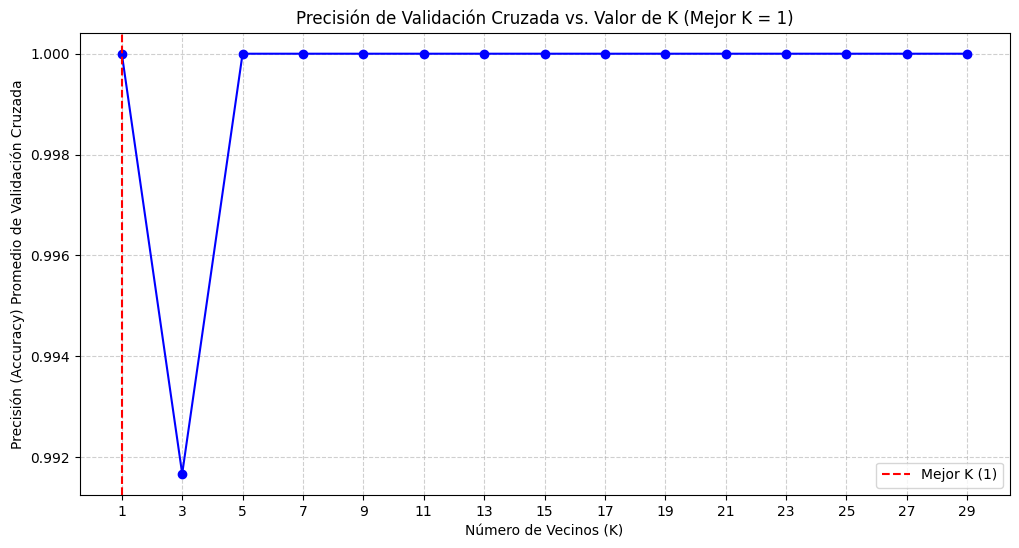

In [13]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

# --- 1. PREPARACIÓN DE DATOS DE EJEMPLO ---
# NOTA: En tu caso real, X_knn_imputed y y deben provenir de la sección 4 
# del código anterior (los datos ya imputados con KNN Imputer).
# Aquí se usa un ejemplo de datos limpios para que el código sea ejecutable.

# Simulación de carga de datos ya limpios (X_raw es la base, y es el target)
# Asumimos que la imputación con KNN y la codificación de categóricas ya se hizo
# y que X_knn_imputed es el resultado.

# Creamos datos dummy para que el código funcione sin el archivo completo
try:
    # Intenta cargar los datos reales si están disponibles
    df_temp = pd.read_csv('diabetic_data.csv').replace('?', np.nan).dropna(axis=0, how='any')
    # Preprocesamiento mínimo
    for col in df_temp.columns:
        if df_temp[col].dtype == 'object':
            if col != 'readmitted':
                df_temp[col] = pd.factorize(df_temp[col])[0]
    
    df_temp = df_temp.drop(columns=['encounter_id', 'patient_nbr'], errors='ignore')
    X_sample = df_temp.drop('readmitted', axis=1).select_dtypes(include=[np.number]).sample(n=1000, random_state=42)
    y_sample = df_temp.loc[X_sample.index, 'readmitted'].replace({'NO': 0, '<30': 1, '>30': 1})
    
    # Simulación de datos ya imputados y listos
    X_knn_imputed = X_sample.values 
    y = y_sample.values

except Exception as e:
    # Si la carga falla, crea datos aleatorios para la demostración
    print(f"Advertencia: Usando datos de ejemplo aleatorios para la demostración. Error: {e}")
    from sklearn.datasets import load_iris
    iris = load_iris()
    X_knn_imputed = iris.data
    y = (iris.target > 0).astype(int) # Target binario


# ---------------------------------------------------------
# 2. ESCALADO DE DATOS Y DIVISIÓN
# ---------------------------------------------------------
# Escalamos los datos (vital para KNN)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_knn_imputed)

# Dividimos el dataset para tener un conjunto de PRUEBA final (hold-out set)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# ---------------------------------------------------------
# 3. MÉTODO DE GRID SEARCH (BÚSQUEDA DEL MEJOR K)
# ---------------------------------------------------------

# Definimos el rango de K que queremos probar (Hiperparámetros a buscar)
# Es común probar números impares para evitar empates en la votación.
param_grid = {'n_neighbors': np.arange(1, 31, 2)} 
# Esto probará K = 1, 3, 5, 7, 9, ..., 29

# Inicializamos el modelo (KNN)
knn_base = KNeighborsClassifier()

# Configuramos Grid Search con Cross-Validation (CV=5)
# GridSearchCV probará cada valor de K 5 veces en diferentes subconjuntos de datos de entrenamiento.
grid_search = GridSearchCV(
    estimator=knn_base, 
    param_grid=param_grid, 
    cv=5, 
    scoring='accuracy', # La métrica que usaremos para medir el rendimiento
    n_jobs=-1,         # Usar todos los núcleos del CPU
    verbose=1          # Muestra el progreso
)

print("Iniciando búsqueda en cuadrícula (Grid Search) para el mejor K...")
# Ejecutamos la búsqueda sobre el conjunto de ENTRENAMIENTO
grid_search.fit(X_train, y_train)

# ---------------------------------------------------------
# 4. RESULTADOS Y EVALUACIÓN FINAL
# ---------------------------------------------------------

# El mejor valor de K encontrado por la búsqueda
best_k = grid_search.best_params_['n_neighbors']
print(f"\n--- Resultados de la Búsqueda ---")
print(f"El mejor valor de K encontrado (K más óptimo): {best_k}")
print(f"Precisión promedio (CV Score) con el mejor K: {grid_search.best_score_:.4f}")

# Obtenemos el mejor modelo entrenado
best_knn_model = grid_search.best_estimator_

# Evaluación final en el conjunto de PRUEBA (datos nunca vistos)
y_pred = best_knn_model.predict(X_test)
final_accuracy = accuracy_score(y_test, y_pred)

print(f"Precisión FINAL en el set de prueba (con K={best_k}): {final_accuracy:.4f}")

# ---------------------------------------------------------
# 5. VISUALIZACIÓN DE LOS RESULTADOS
# ---------------------------------------------------------
# Gráfico que muestra la precisión de todos los K probados
cv_results = pd.DataFrame(grid_search.cv_results_)
mean_scores = cv_results['mean_test_score']

plt.figure(figsize=(12, 6))
plt.plot(np.arange(1, 31, 2), mean_scores, marker='o', linestyle='-', color='blue')
plt.title(f'Precisión de Validación Cruzada vs. Valor de K (Mejor K = {best_k})')
plt.xlabel('Número de Vecinos (K)')
plt.ylabel('Precisión (Accuracy) Promedio de Validación Cruzada')
plt.xticks(np.arange(1, 31, 2))
plt.axvline(x=best_k, color='red', linestyle='--', label=f'Mejor K ({best_k})')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

### Balanceo con SMOTE o class_weight = 'balanced'